# RESPON MODUL 5 - Doomsday (Avengers)
Wavelet Decomposition, Thresholding, Morphology, dan Rekonstruksi

## Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Fungsi Utilitas

In [2]:
def normalisasi(image):
    image = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
    return image.astype(np.uint8)

def convolve_rows(image, kernel):
    kernel = np.asarray(kernel).ravel()
    k = len(kernel)
    pad = k // 2
    padded = np.pad(image, ((0, 0), (pad, pad)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i, j] = np.sum(padded[i, j:j+k] * kernel)
    return out

def convolve_cols(image, kernel):
    kernel = np.asarray(kernel).ravel()
    k = len(kernel)
    pad = k // 2
    padded = np.pad(image, ((pad, pad), (0, 0)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i, j] = np.sum(padded[i:i+k, j] * kernel)
    return out

LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HPF = np.array([1/np.sqrt(2), -(1/np.sqrt(2))])

## Fungsi Dekomposisi Wavelet

In [3]:
def downsample_rows(image):
    return image[::2, :]

def downsample_cols(image):
    return image[:, ::2]

def downRowConvolve(image, filt_row):
    conv = convolve_rows(image, filt_row)
    return downsample_cols(conv)

def downColConvolve(image, filt_col):
    conv = convolve_cols(image, filt_col)
    return downsample_rows(conv)

def dekomposisi(image, low_filter=LPF, high_filter=HPF):
    low_row  = downRowConvolve(image, low_filter)
    high_row = downRowConvolve(image, high_filter)

    LL = downColConvolve(low_row,  low_filter)
    LH = downColConvolve(low_row,  high_filter)
    HL = downColConvolve(high_row, low_filter)
    HH = downColConvolve(high_row, high_filter)

    LL = normalisasi(LL)
    LH = normalisasi(LH)
    HL = normalisasi(HL)
    HH = normalisasi(HH)

    return LL, LH, HL, HH

## Fungsi Rekonstruksi Wavelet

In [4]:
def upsample_rows(image):
    h, w = image.shape
    up = np.zeros((h * 2, w), dtype=np.float32)
    up[::2, :] = image
    return up

def upsample_cols(image):
    h, w = image.shape
    up = np.zeros((h, w * 2), dtype=np.float32)
    up[:, ::2] = image
    return up

def rekonstruksi(LL, LH, HL, HH, low_filter=LPF, high_filter=HPF):
    low_part = (
        convolve_cols(upsample_rows(LL.astype(np.float32)), low_filter) +
        convolve_cols(upsample_rows(LH.astype(np.float32)), high_filter)
    )
    high_part = (
        convolve_cols(upsample_rows(HL.astype(np.float32)), low_filter) +
        convolve_cols(upsample_rows(HH.astype(np.float32)), high_filter)
    )
    hasil = (
        convolve_rows(upsample_cols(low_part), low_filter) +
        convolve_rows(upsample_cols(high_part), high_filter)
    )
    return hasil

## 1. Baca Gambar doomsday.jpg dan Ubah ke Grayscale

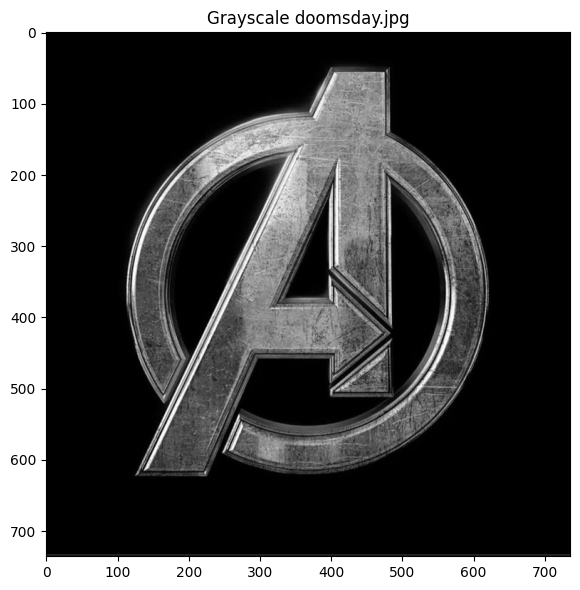

Ukuran gambar: (736, 736)


In [5]:
img_bgr = cv2.imread('doomsday.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale doomsday.jpg')
plt.tight_layout()
plt.show()

print(f'Ukuran gambar: {img_gray.shape}')

## 2. Dekomposisi Level 1

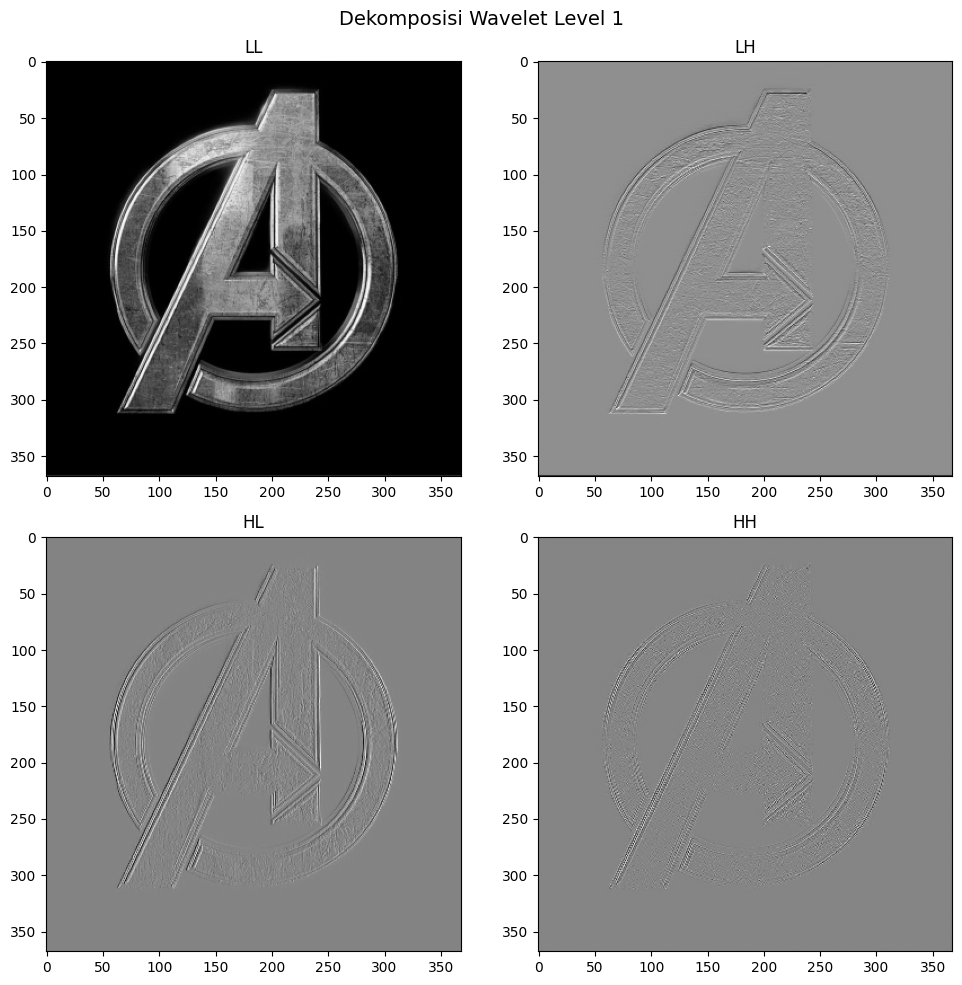

Ukuran subband:
  LL: (368, 368)
  LH: (368, 368)
  HL: (368, 368)
  HH: (368, 368)


In [6]:
LL, LH, HL, HH = dekomposisi(img_gray.astype(np.float32))

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = ['LL', 'LH', 'HL', 'HH']
subbands = [LL, LH, HL, HH]

for ax, title, sub in zip(axes.ravel(), titles, subbands):
    ax.imshow(sub, cmap='gray')
    ax.set_title(title)

plt.suptitle('Dekomposisi Wavelet Level 1', fontsize=14)
plt.tight_layout()
plt.show()

print('Ukuran subband:')
for t, s in zip(titles, subbands):
    print(f'  {t}: {s.shape}')

## 3. Thresholding pada Subband LH, HL, HH (threshold = 150)

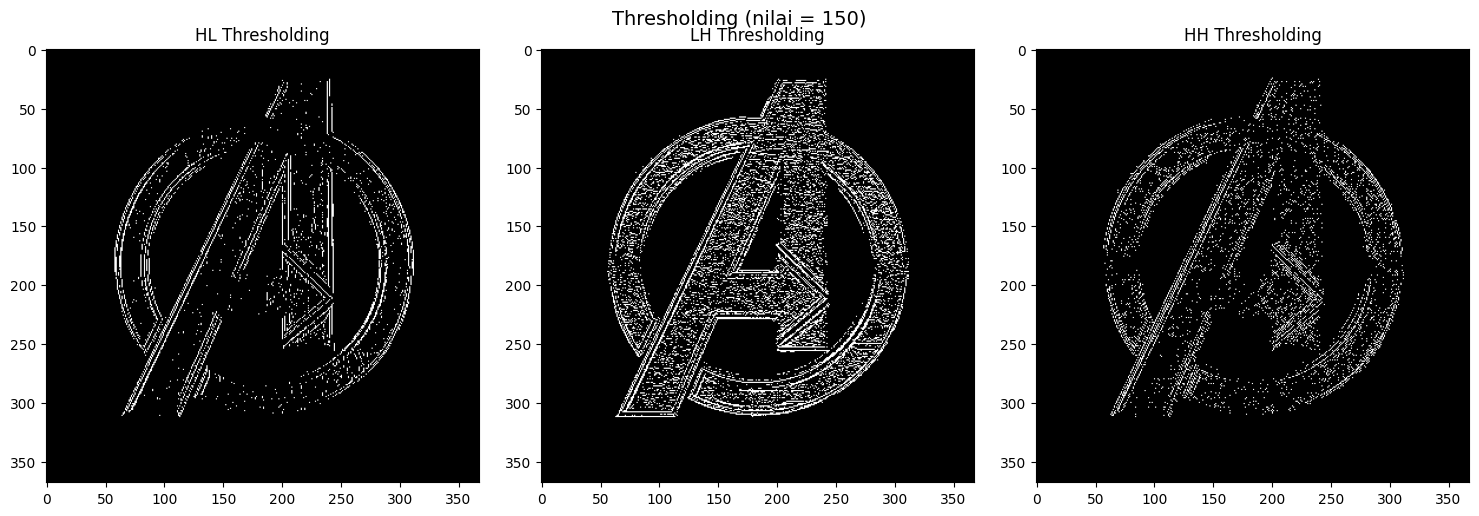

HL_thresh: piksel putih = 3.69%
LH_thresh: piksel putih = 9.03%
HH_thresh: piksel putih = 4.04%


In [ ]:
threshold = 150

# Thresholding: piksel di atas threshold -> 255, lainnya -> 0
HL_thresh = np.where(HL > threshold, 255, 0).astype(np.uint8)
LH_thresh = np.where(LH > threshold, 255, 0).astype(np.uint8)
HH_thresh = np.where(HH > threshold, 255, 0).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
                          [HL_thresh, LH_thresh, HH_thresh],
                          ['HL Thresholding', 'LH Thresholding', 'HH Thresholding']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)

plt.suptitle(f'Thresholding (nilai = {threshold})', fontsize=14)
plt.tight_layout()
plt.show()

for name, t in zip(['HL', 'LH', 'HH'], [HL_thresh, LH_thresh, HH_thresh]):
    white_pct = np.sum(t == 255) / t.size * 100
    print(f'{name}_thresh: piksel putih = {white_pct:.2f}%')

## 4. Operasi Morfologi Closing pada Hasil Thresholding

Kernel morfologi (closing):
[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


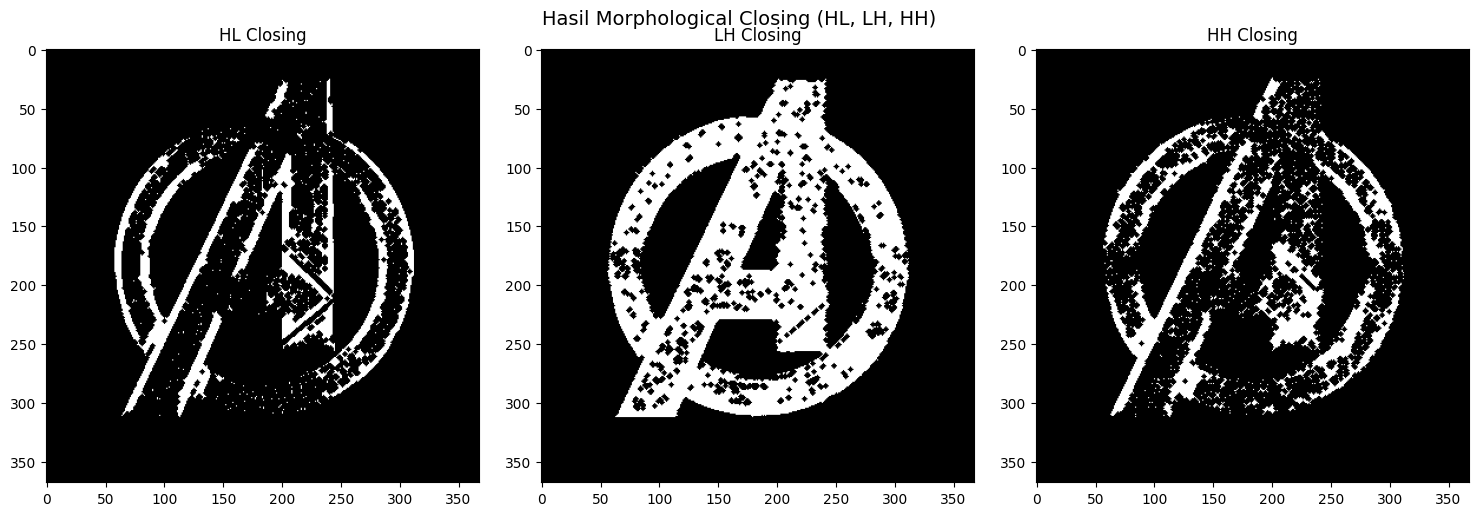

In [ ]:
kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)

print('Kernel morfologi (closing):')
print(kernel5)

# Closing 
HL_closing = cv2.morphologyEx(HL_thresh, cv2.MORPH_CLOSE, kernel5)
LH_closing = cv2.morphologyEx(LH_thresh, cv2.MORPH_CLOSE, kernel5)
HH_closing = cv2.morphologyEx(HH_thresh, cv2.MORPH_CLOSE, kernel5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
                          [HL_closing, LH_closing, HH_closing],
                          ['HL Closing', 'LH Closing', 'HH Closing']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)

plt.suptitle('Hasil Morphological Closing (HL, LH, HH)', fontsize=14)
plt.tight_layout()
plt.show()

### Analisis Karakteristik Hasil Closing

**HL (Vertical Detail / Closing):**  
Subband HL menangkap tepi vertikal dari gambar (perubahan intensitas arah vertikal). Setelah closing, celah kecil pada garis-garis vertikal logo Avengers tertutup, sehingga kontur vertikal terlihat lebih menyambung dan solid. Region putih menjadi lebih tebal dan kompak.

**LH (Horizontal Detail / Closing):**  
Subband LH menangkap tepi horizontal. Setelah closing, garis-garis horizontal yang sebelumnya terputus-putus menjadi lebih kontinu. Bagian atas dan bawah lingkaran logo serta garis melintang huruf A tampak lebih jelas dan tersambung.

**HH (Diagonal Detail / Closing):**  
Subband HH menangkap tepi diagonal. Karena informasi diagonal cenderung lebih sparse, hasil closing memperlihatkan penggabungan titik-titik tepi diagonal yang semula terpisah menjadi blob/region yang lebih besar. Detail diagonal logo seperti sisi miring huruf A dan lengkungan lingkaran lebih tampak setelah closing.

## 5. Rekonstruksi

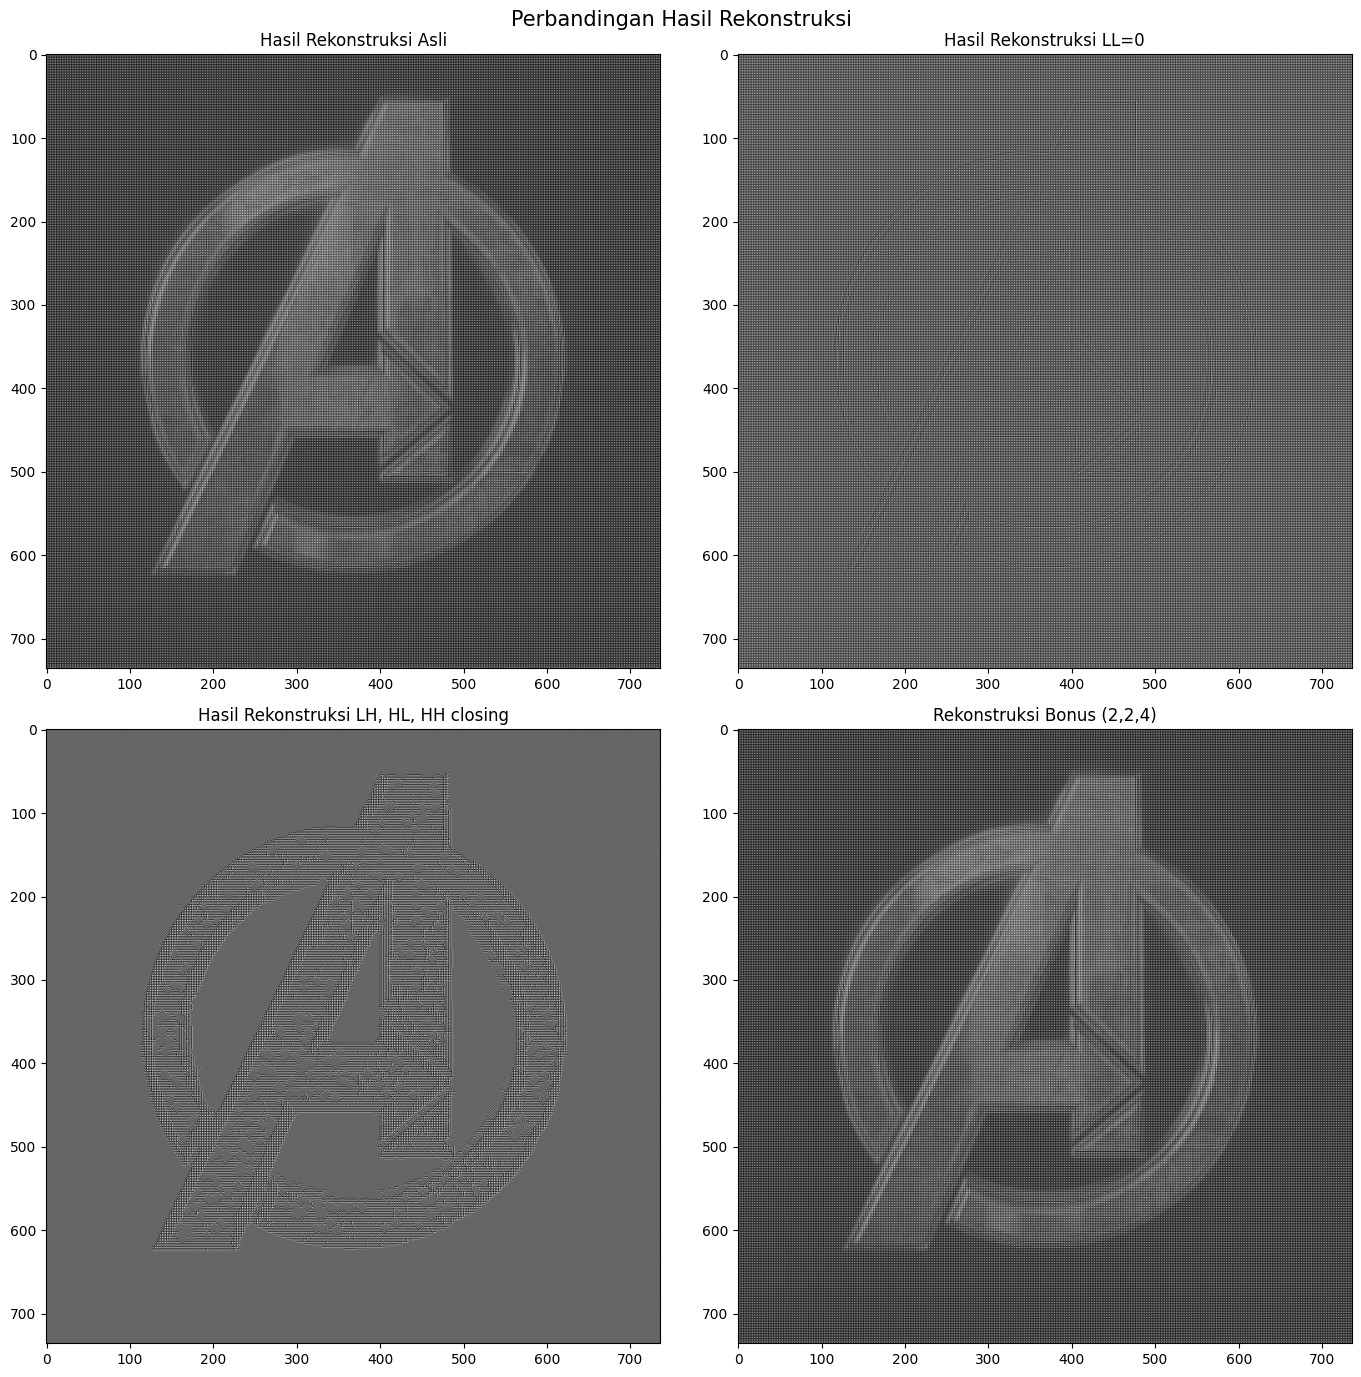

In [ ]:
# a. Rekonstruksi dengan LL, LH, HL, HH asli
hasil_asli = rekonstruksi(LL, LH, HL, HH)

# b. Rekonstruksi dengan LL=0, LH, HL, HH level 1
LL_zeros = np.zeros_like(LL, dtype=np.float32)
hasil_ll0 = rekonstruksi(LL_zeros, LH, HL, HH)

# c. Rekonstruksi dengan LL=0, LH, HL, HH setelah closing
hasil_closing = rekonstruksi(LL_zeros, LH_closing, HL_closing, HH_closing)

# d. Bonus: rekonstruksi subplot (2,2,4) posisi bawah kanan
# Gunakan rekonstruksi asli (LL, LH, HL, HH) sebagai subplot ke-4
hasil_bonus = rekonstruksi(LL, LH, HL, HH)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# subplot (2,2,1) - atas kiri
axes[0, 0].imshow(normalisasi(hasil_asli), cmap='gray')
axes[0, 0].set_title('Hasil Rekonstruksi Asli')

# subplot (2,2,2) - atas kanan
axes[0, 1].imshow(normalisasi(hasil_ll0), cmap='gray')
axes[0, 1].set_title('Hasil Rekonstruksi LL=0')

# subplot (2,2,3) - bawah kiri
axes[1, 0].imshow(normalisasi(hasil_closing), cmap='gray')
axes[1, 0].set_title('Hasil Rekonstruksi LH, HL, HH closing')

# subplot (2,2,4) - bawah kanan (bonus)
# Rekonstruksi dengan LL, LH, HL, HH asli
axes[1, 1].imshow(normalisasi(hasil_bonus), cmap='gray')
axes[1, 1].set_title('Rekonstruksi Bonus (2,2,4)')

plt.suptitle('Perbandingan Hasil Rekonstruksi', fontsize=15)
plt.tight_layout()
plt.show()

### Analisis Hasil Rekonstruksi

**a. Rekonstruksi Asli (LL + LH + HL + HH):**  
Gambar hasil rekonstruksi sangat mirip dengan gambar grayscale asli. Semua komponen frekuensi (rendah dan tinggi) digabungkan kembali, sehingga informasi spasial, tekstur, dan tepi dari logo Avengers terjaga dengan baik. Sedikit perbedaan dari asli disebabkan proses normalisasi dan rounding.

**b. Rekonstruksi dengan LL=0 (tanpa komponen frekuensi rendah):**  
Hasilnya hanya berisi komponen frekuensi tinggi (tepi/detail). Gambar tampak abu-abu datar dengan garis-garis halus yang menyerupai outline logo. Tanpa LL, informasi intensitas dasar (background gelap, area terang logo) hilang — yang tersisa hanya detail tepi.

**c. Rekonstruksi dengan LL=0 + LH, HL, HH setelah closing:**  
Dibanding (b), garis tepi terlihat lebih tebal dan tersambung karena proses closing menutup celah pada subband detail. Namun karena LL tetap nol, intensitas keseluruhan masih flat/abu-abu. Detail tepi yang direkonstruksi lebih smooth dan bold dibanding rekonstruksi (b).